# PREDICTIVE ANALYSIS CIA - EMPLOYEE ATTRITION PREDICTION

# Submitted by Lekhaa (2423235), Haripreeth (2423224) and Aiswarya (2423204)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
sns.set_style("whitegrid")

In [44]:
df=pd.read_excel(r"C:\Users\Lekhaa\Downloads\employee_attrition-dataset.xlsx")

In [45]:
df

,Age,Attrition,Gender,JobLevel,JobSatisfaction,MaritalStatus,MonthlyIncome,PerformanceRating,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
0,41,Yes,Female,2,4,Single,5993,3,1,6,4,0
1,49,No,Male,2,2,Married,5130,4,3,10,7,1
2,37,Yes,Male,1,3,Single,2090,3,3,0,0,0
3,33,No,Female,1,3,Married,2909,3,3,8,7,3
4,27,No,Male,1,2,Married,3468,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Male,2,4,Married,2571,3,3,5,2,0
1466,39,No,Male,3,1,Married,9991,3,3,7,7,1
1467,27,No,Male,2,2,Married,6142,4,3,6,2,0
1468,49,No,Male,2,2,Married,5390,3,2,9,6,0


In [46]:
df.head()

,Age,Attrition,Gender,JobLevel,JobSatisfaction,MaritalStatus,MonthlyIncome,PerformanceRating,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
0,41,Yes,Female,2,4,Single,5993,3,1,6,4,0
1,49,No,Male,2,2,Married,5130,4,3,10,7,1
2,37,Yes,Male,1,3,Single,2090,3,3,0,0,0
3,33,No,Female,1,3,Married,2909,3,3,8,7,3
4,27,No,Male,1,2,Married,3468,3,3,2,2,2


In [47]:
df.tail()

,Age,Attrition,Gender,JobLevel,JobSatisfaction,MaritalStatus,MonthlyIncome,PerformanceRating,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
1465,36,No,Male,2,4,Married,2571,3,3,5,2,0
1466,39,No,Male,3,1,Married,9991,3,3,7,7,1
1467,27,No,Male,2,2,Married,6142,4,3,6,2,0
1468,49,No,Male,2,2,Married,5390,3,2,9,6,0
1469,34,No,Male,2,3,Married,4404,3,4,4,3,1


In [48]:
df.shape

(1470, 12)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Gender                   1470 non-null   object
 3   JobLevel                 1470 non-null   int64 
 4   JobSatisfaction          1470 non-null   int64 
 5   MaritalStatus            1470 non-null   object
 6   MonthlyIncome            1470 non-null   int64 
 7   PerformanceRating        1470 non-null   int64 
 8   WorkLifeBalance          1470 non-null   int64 
 9   YearsAtCompany           1470 non-null   int64 
 10  YearsInCurrentRole       1470 non-null   int64 
 11  YearsSinceLastPromotion  1470 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 137.9+ KB


In [59]:
df.describe().round(2)

,Age,JobLevel,JobSatisfaction,MonthlyIncome,PerformanceRating,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,2.06,2.73,6502.93,3.15,2.76,7.01,4.23,2.19
std,9.14,1.11,1.10,4707.96,0.36,0.71,6.13,3.62,3.22
min,18.00,1.00,1.00,1009.00,3.00,1.00,0.00,0.00,0.00
25%,30.00,1.00,2.00,2911.00,3.00,2.00,3.00,2.00,0.00
50%,36.00,2.00,3.00,4919.00,3.00,3.00,5.00,3.00,1.00
75%,43.00,3.00,4.00,8379.00,3.00,3.00,9.00,7.00,3.00
max,60.00,5.00,4.00,19999.00,4.00,4.00,40.00,18.00,15.00


# The analysis indicates that variables such as Monthly Income, Job Satisfaction, Work-Life Balance, Years at Company, Years in Current Role and Years Since Last Promotion exhibit meaningful variability, making them strong candidates for predicting employee attrition. In contrast, Performance Rating shows minimal variation, suggesting it may have limited influence on predicting employee turnover.

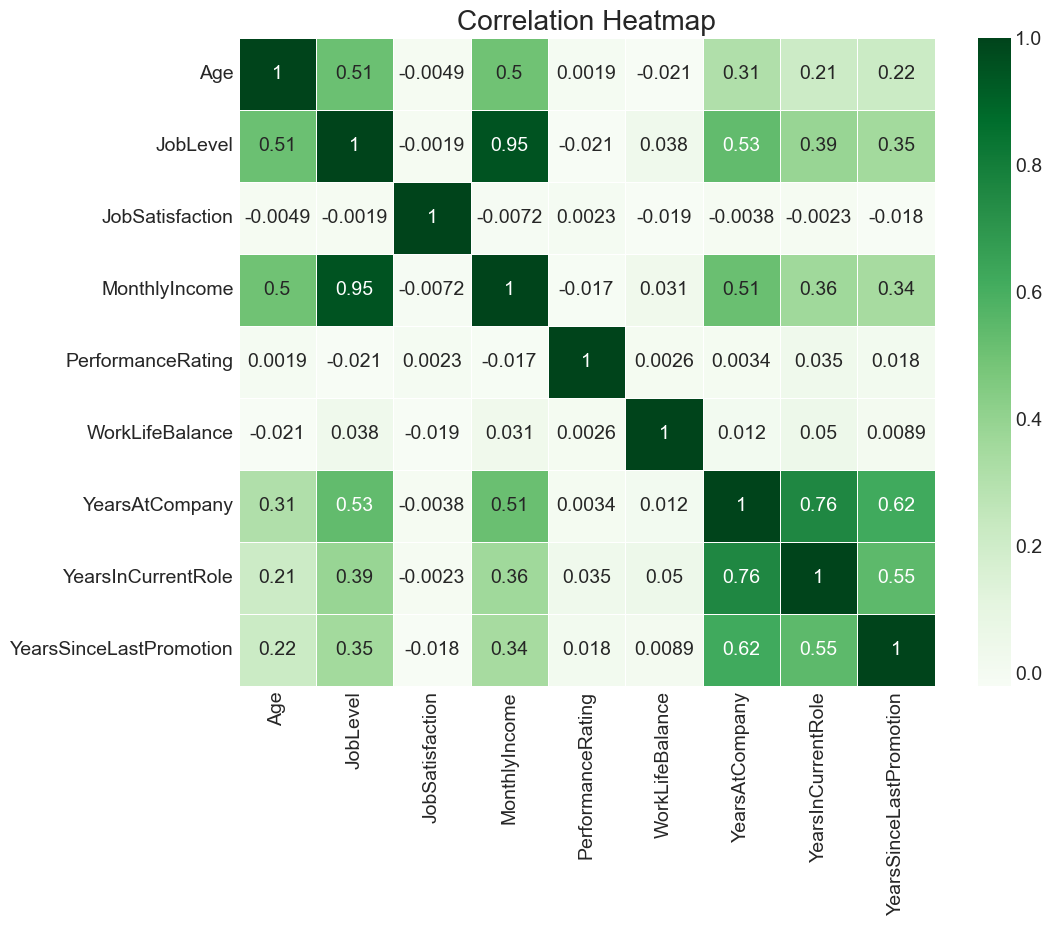

In [56]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='Greens',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

# The correlation analysis shows that Job Level and Monthly Income have a very strong positive correlation (0.95), indicating that employees in higher job levels tend to earn significantly higher salaries. Years at Company is strongly correlated with Years in Current Role (0.76) and Years Since Last Promotion (0.62), suggesting that longer-tenured employees generally spend more time in the same role and experience longer promotion intervals.

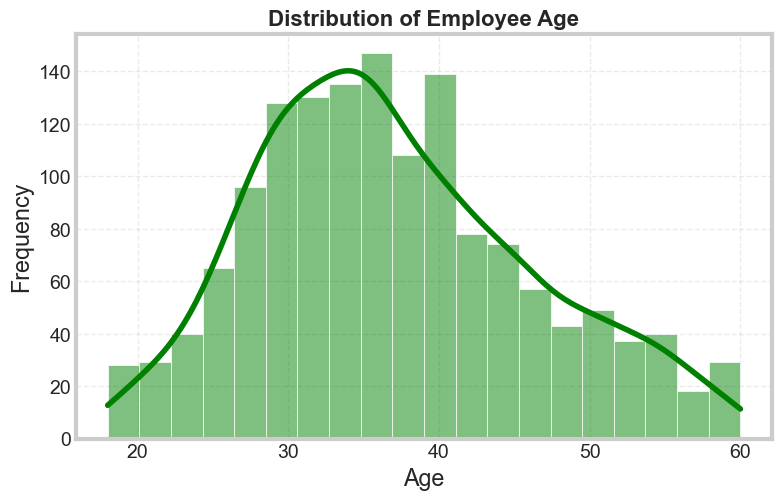

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True, color="green")
plt.title("Distribution of Employee Age", fontsize=16, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# The histogram indicates that the majority of employees are between 30 and 40 years of age, with the highest concentration around 35 years. The age distribution is approximately right-skewed, showing fewer employees in the older age groups above 50 years.

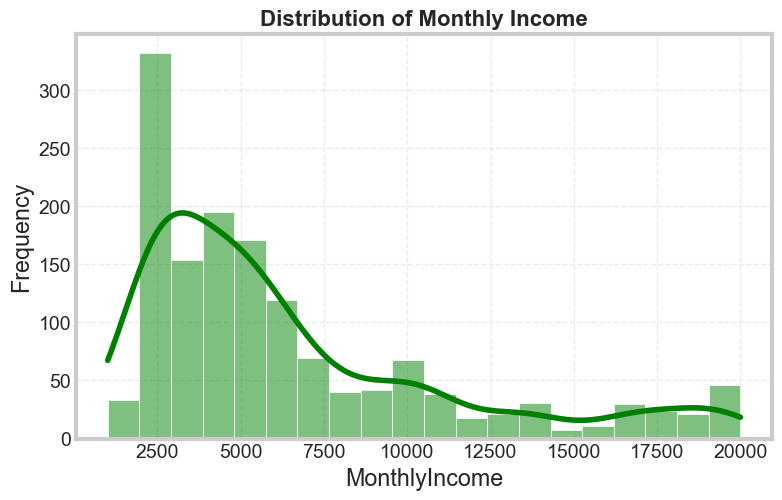

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyIncome"], bins=20, kde=True, color="green")
plt.title("Distribution of Monthly Income", fontsize=16, fontweight='bold')
plt.xlabel("MonthlyIncome")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

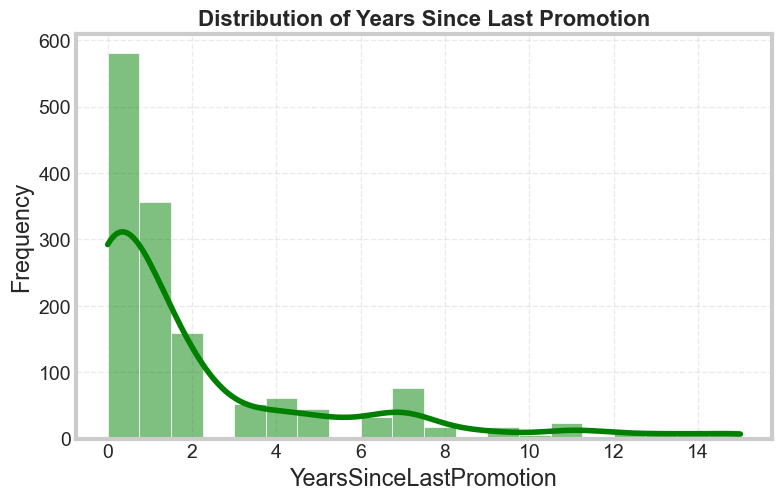

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(df["YearsSinceLastPromotion"], bins=20, kde=True, color="green")
plt.title("Distribution of Years Since Last Promotion", fontsize=16, fontweight='bold')
plt.xlabel("YearsSinceLastPromotion")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# The distribution is highly right-skewed, with only a few employees waiting more than 10 years for a promotion. This suggests that while promotions are relatively frequent for most employees, a small group experiences prolonged periods without career advancement, which may increase the risk of attrition.

C:\Users\Lekhaa\AppData\Local\Temp\ipykernel_17036\3059624670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


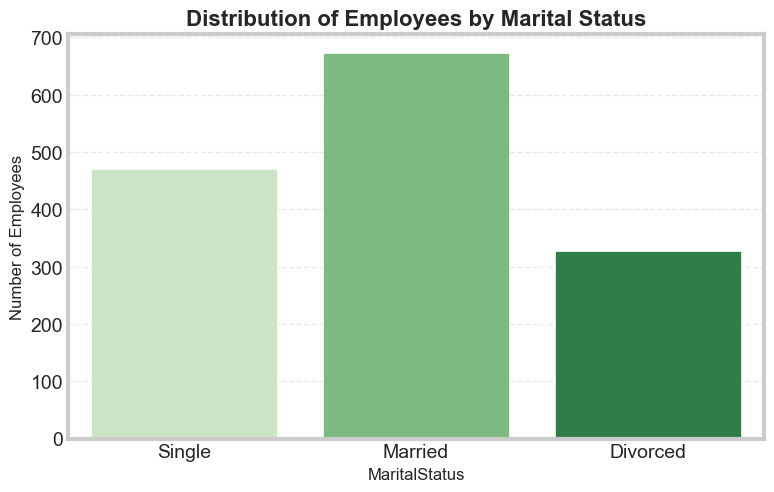

In [68]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="MaritalStatus",
    palette="Greens"
)
plt.title("Distribution of Employees by Marital Status", fontsize=16, fontweight="bold")
plt.xlabel("MaritalStatus", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# The count plot indicates that married employees form the largest group in the organization, followed by single employees, while divorced employees represent the smallest proportion. This reflects a workforce predominantly consisting of married individuals. Marital status can be further analyzed to determine whether it influences employee attrition and retention patterns.

C:\Users\Lekhaa\AppData\Local\Temp\ipykernel_17036\3713573349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


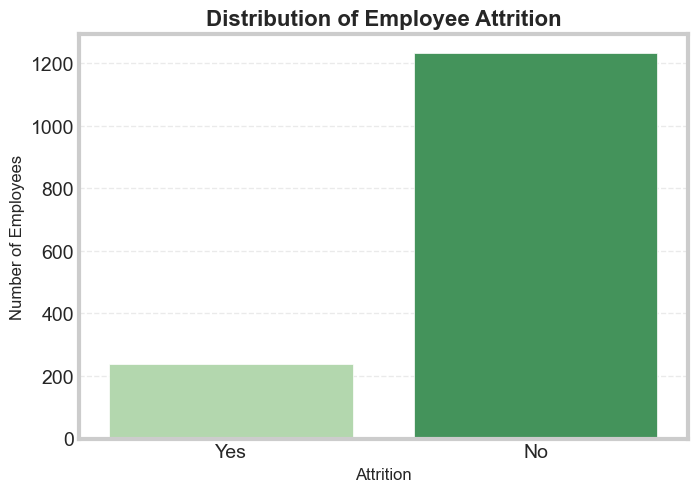

In [69]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="Attrition",
    palette="Greens"
)
plt.title("Distribution of Employee Attrition", fontsize=16, fontweight="bold")
plt.xlabel("Attrition", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

C:\Users\Lekhaa\AppData\Local\Temp\ipykernel_17036\816400900.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


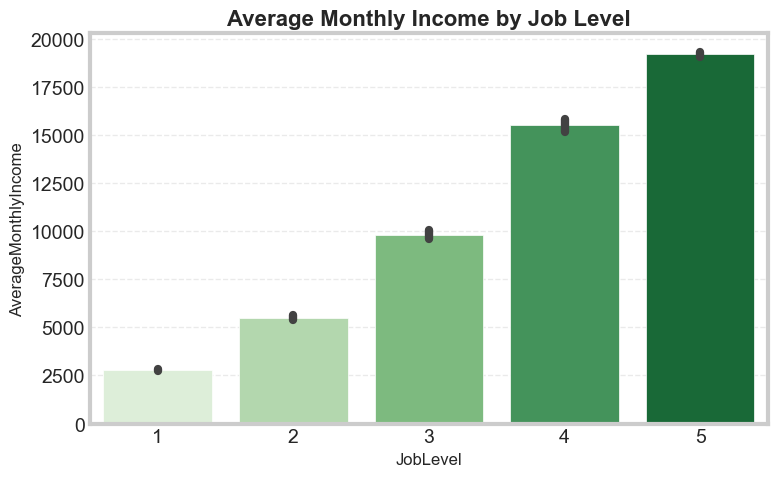

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="JobLevel",
    y="MonthlyIncome",
    estimator="mean",
    palette="Greens"
)

plt.title("Average Monthly Income by Job Level", fontsize=16, fontweight="bold")
plt.xlabel("JobLevel", fontsize=12)
plt.ylabel("AverageMonthlyIncome", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

C:\Users\Lekhaa\AppData\Local\Temp\ipykernel_17036\1481013877.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


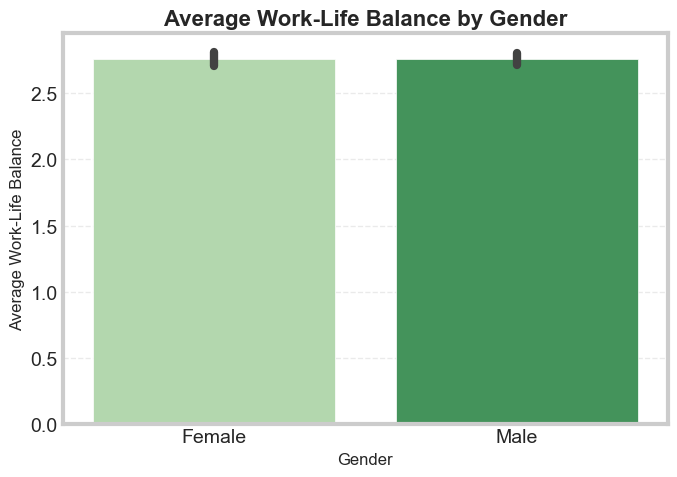

In [67]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Gender",
    y="WorkLifeBalance",
    estimator="mean",
    palette="Greens"
)

plt.title("Average Work-Life Balance by Gender", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Average Work-Life Balance", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

C:\Users\Lekhaa\AppData\Local\Temp\ipykernel_17036\400687970.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


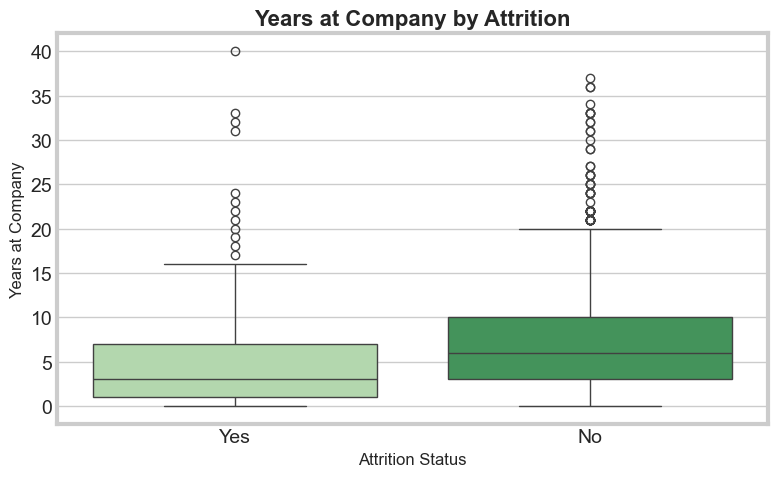

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany",
    palette="Greens"
)

plt.title("Years at Company by Attrition", fontsize=16, fontweight="bold")
plt.xlabel("Attrition Status", fontsize=12)
plt.ylabel("Years at Company", fontsize=12)

plt.tight_layout()
plt.show()

# The box plot reveals that employees who did not leave the organization (Attrition = No) generally have a higher median tenure than those who left. Employees with attrition tend to have fewer years at the company, suggesting that newer employees are more likely to resign. Several outliers exist in both groups, indicating that a small number of employees remain with the company for exceptionally long periods.

C:\Users\Lekhaa\AppData\Local\Temp\ipykernel_17036\1700933837.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


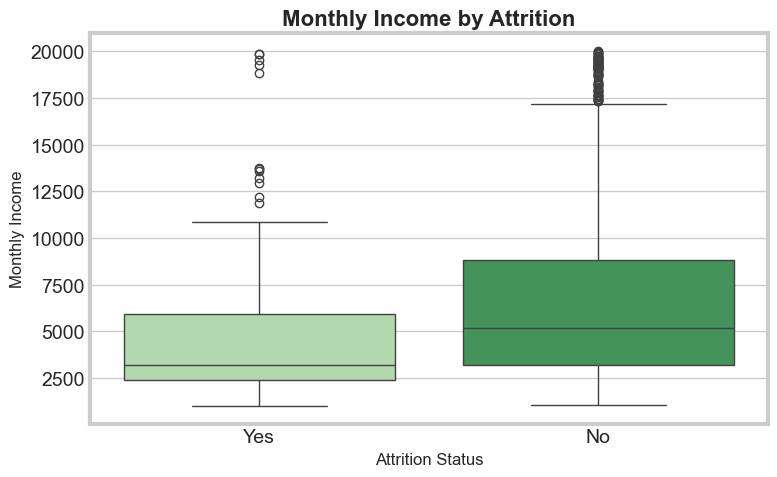

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    palette="Greens"
)

plt.title("Monthly Income by Attrition", fontsize=16, fontweight="bold")
plt.xlabel("Attrition Status", fontsize=12)
plt.ylabel("Monthly Income", fontsize=12)

plt.tight_layout()
plt.show()

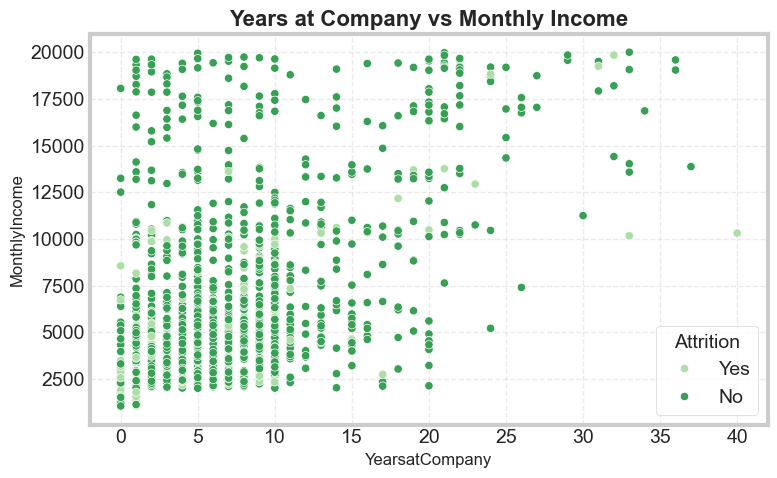

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="YearsAtCompany",
    y="MonthlyIncome",
    hue="Attrition",
    palette="Greens"
)

plt.title("Years at Company vs Monthly Income", fontsize=16, fontweight="bold")
plt.xlabel("YearsatCompany", fontsize=12)
plt.ylabel("MonthlyIncome", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# The scatter plot shows a general positive relationship between years at the company and monthly income, with employees who have longer tenure tending to earn higher salaries. However, the data points are widely dispersed, indicating that tenure alone does not determine income. Employees with and without attrition are distributed across the plot, suggesting that multiple factors beyond salary and experience contribute to employee turnover.

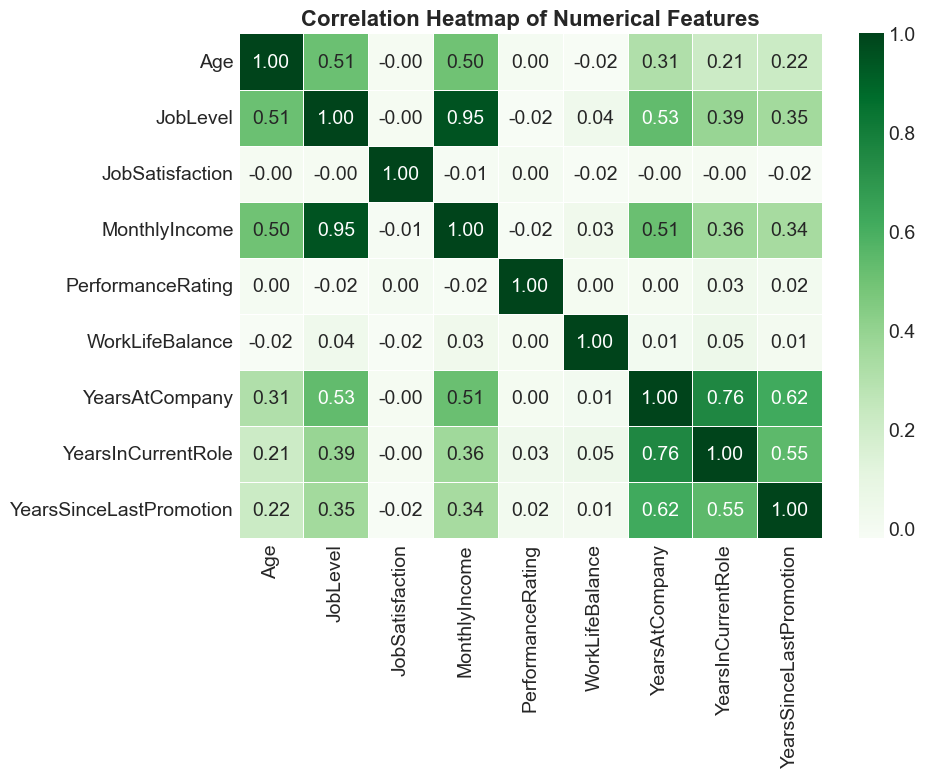

In [73]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

In [74]:
pivot_income = pd.pivot_table(
    df,
    values="MonthlyIncome",
    index="JobLevel",
    aggfunc="mean"
)

print(pivot_income)

          MonthlyIncome
JobLevel               
1           2786.915285
2           5502.277154
3           9817.252294
4          15503.783019
5          19191.826087


# The pivot table shows that the average monthly income increases steadily with job level, rising from 2,786 at Job Level 1 to 19,192 at Job Level 5. This indicates a strong positive relationship between job level and salary, suggesting that higher positions are associated with significantly greater earnings.

In [77]:
attrition_percent = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(attrition_percent)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


# The attrition analysis reveals that 83.88% of employees remained with the organization, while 16.12% left. This indicates that employee retention is generally high, although the attrition rate is significant enough to warrant analysis and targeted retention strategies.

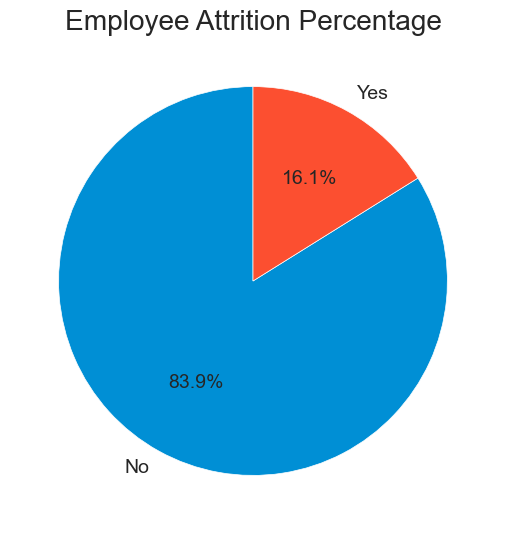

In [88]:
plt.figure(figsize=(6,6))
plt.pie(
    attrition_percent,
    labels=attrition_percent.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Employee Attrition Percentage")
plt.show()

In [89]:
salary = df.groupby("Attrition")["MonthlyIncome"].mean()
print(salary)

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


In [83]:
age = df.groupby("Attrition")["Age"].mean()
print(age)

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64


In [82]:
satisfaction = df.groupby("Attrition")["JobSatisfaction"].mean()
print(satisfaction)

Attrition
No     2.778589
Yes    2.468354
Name: JobSatisfaction, dtype: float64


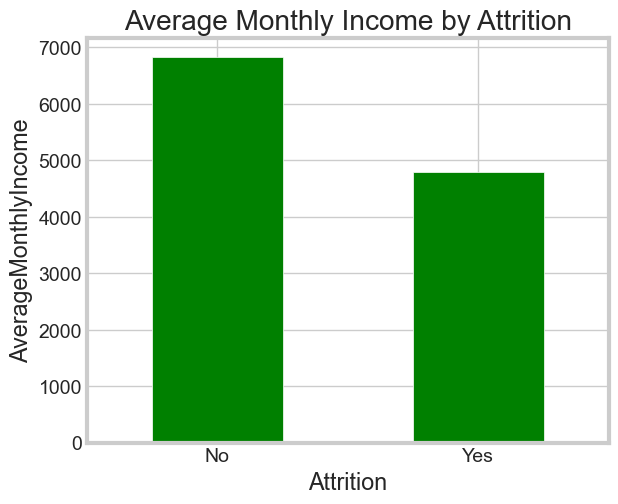

In [85]:
group = df.groupby("Attrition")["MonthlyIncome"].mean()
plt.figure(figsize=(6,5))
group.plot(kind="bar", color="green")
plt.title("Average Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("AverageMonthlyIncome")
plt.xticks(rotation=0)
plt.show()

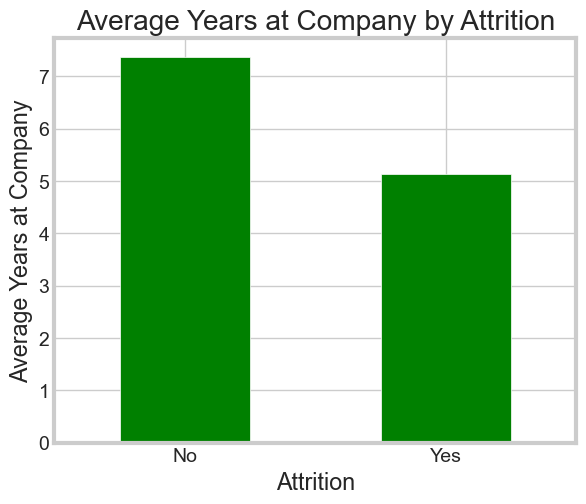

In [91]:
group = df.groupby("Attrition")["YearsAtCompany"].mean()
plt.figure(figsize=(6,5))
group.plot(kind="bar", color="green")
plt.title("Average Years at Company by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Years at Company")
plt.xticks(rotation=0)
plt.show()

In [93]:
gender_attrition = pd.crosstab(
    df["Gender"],
    df["Attrition"]
)
print(gender_attrition)

Attrition   No  Yes
Gender             
Female     501   87
Male       732  150


In [94]:
joblevel_attrition = pd.crosstab(
    df["JobLevel"],
    df["Attrition"]
)
print(joblevel_attrition)

Attrition   No  Yes
JobLevel           
1          400  143
2          482   52
3          186   32
4          101    5
5           64    5


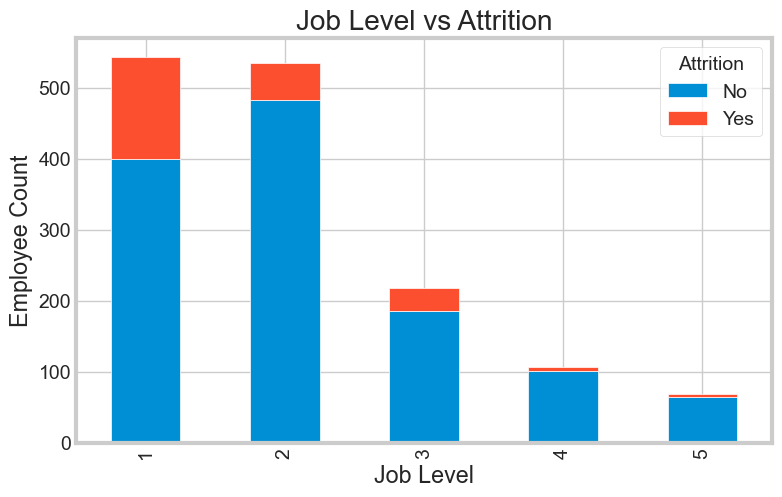

In [98]:
pd.crosstab(
    df["JobLevel"],
    df["Attrition"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)
plt.title("Job Level vs Attrition")
plt.xlabel("Job Level")
plt.ylabel("Employee Count")
plt.show()

In [99]:
summary = df.groupby("Attrition").agg({
    "Age":"mean",
    "MonthlyIncome":"mean",
    "YearsAtCompany":"mean",
    "JobSatisfaction":"mean",
    "WorkLifeBalance":"mean"
})
print(summary)

                 Age  MonthlyIncome  YearsAtCompany  JobSatisfaction  \
Attrition                                                              
No         37.561233    6832.739659        7.369019         2.778589   
Yes        33.607595    4787.092827        5.130802         2.468354   

           WorkLifeBalance  
Attrition                   
No                2.781022  
Yes               2.658228  


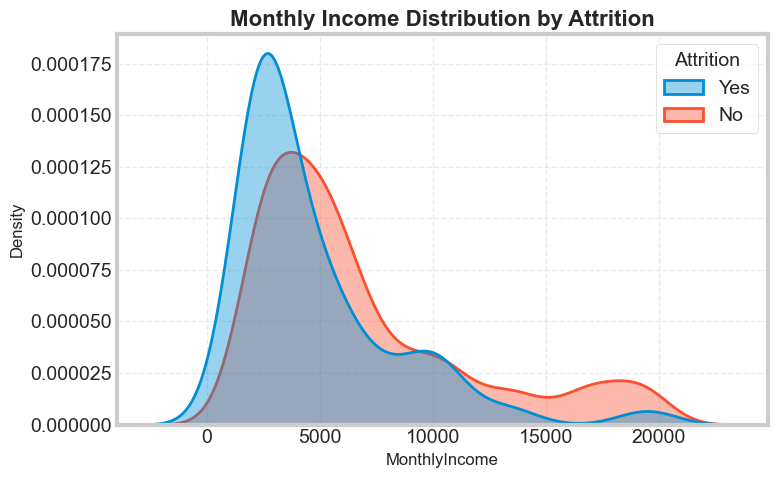

In [100]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="MonthlyIncome",
    hue="Attrition",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2
)

plt.title("Monthly Income Distribution by Attrition", fontsize=16, fontweight="bold")
plt.xlabel("MonthlyIncome", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

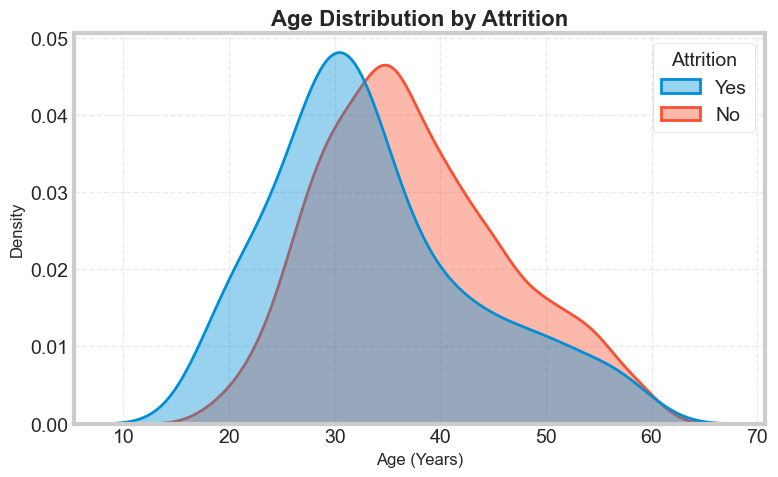

In [101]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="Age",
    hue="Attrition",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2
)

plt.title("Age Distribution by Attrition", fontsize=16, fontweight="bold")
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

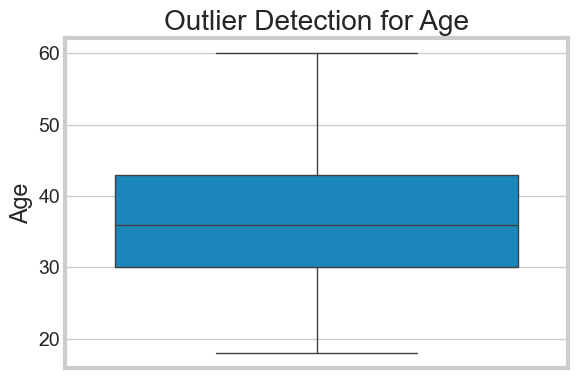

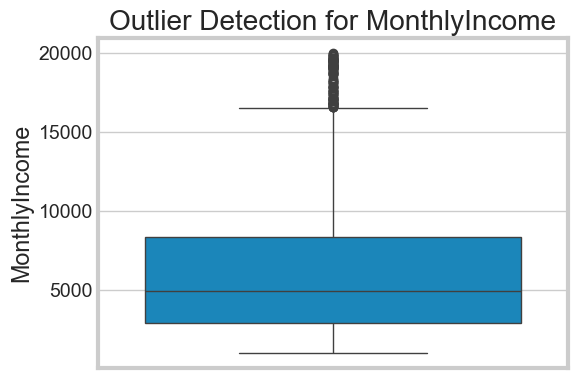

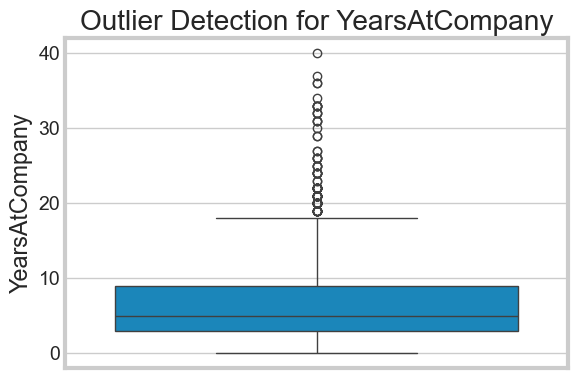

In [103]:
for col in [
    "Age",
    "MonthlyIncome",
    "YearsAtCompany"
]:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Outlier Detection for {col}")
    plt.tight_layout()
    plt.show()

# The box plots indicate that Age has no significant outliers, suggesting a fairly consistent age distribution among employees. In contrast, Monthly Income and Years at Company contain several upper-end outliers, representing employees with exceptionally high salaries and long organizational tenure. These outliers are expected in HR datasets, as they likely correspond to senior or long-serving employees rather than data errors.